# Notebook 05: Explainable AI using Grad-CAM

## Objective

This notebook applies Gradient-weighted Class Activation Mapping (Grad-CAM) to visualize the decision-making process of the trained EfficientNet-B2 model.

The notebook will:

- Load the trained EfficientNet-B2 model
- Generate Grad-CAM heatmaps
- Visualize model attention
- Compare Correct and Incorrect Predictions
- Save Grad-CAM images for research paper figures

Outputs will be stored inside the `results/gradcam/` directory.

In [13]:
# ============================================================
# Import Required Libraries
# ============================================================

from pathlib import Path
import os
import copy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import cv2

import torch
import torch.nn as nn

from torchvision import datasets, transforms

from torchvision.models import (
    efficientnet_b2,
    EfficientNet_B2_Weights
)

sns.set_theme(style="whitegrid")

print("="*60)
print("✅ Libraries Imported Successfully")
print("="*60)

✅ Libraries Imported Successfully


# Project Configuration

Configure all project paths and create the Grad-CAM output directory.

In [14]:
# ============================================================
# Project Configuration
# ============================================================

from pathlib import Path

# If notebook runs inside notebooks/
PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "dataset" / "processed_dataset"

TEST_DIR = DATASET_DIR / "test"

MODEL_PATH = PROJECT_DIR / "models" / "best_model.pth"

RESULTS_DIR = PROJECT_DIR / "results"

GRADCAM_DIR = RESULTS_DIR / "gradcam"

GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Project Directory :", PROJECT_DIR)
print("Dataset Directory :", DATASET_DIR)
print("Model Path        :", MODEL_PATH)
print("Results Directory :", GRADCAM_DIR)
print("Device            :", DEVICE)
print("=" * 60)

Project Directory : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI
Dataset Directory : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset
Model Path        : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/models/best_model.pth
Results Directory : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/results/gradcam
Device            : cuda


# Dataset Configuration

Configure image preprocessing and class information.

In [15]:
# ============================================================
# Dataset Configuration
# ============================================================

IMAGE_SIZE = 260

NUM_CLASSES = 3

CLASS_NAMES = [
    "BACTERIA",
    "NORMAL",
    "VIRUS"
]

transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

print("✅ Dataset configuration completed.")

✅ Dataset configuration completed.


# Load Trained EfficientNet-B2 Model

Load the trained EfficientNet-B2 model and prepare it for Grad-CAM visualization.

In [16]:
# ============================================================
# Load Trained EfficientNet-B2 Model
# ============================================================

weights = EfficientNet_B2_Weights.DEFAULT

model = efficientnet_b2(weights=weights)

in_features = model.classifier[1].in_features

# Must match Notebook 03 exactly
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(DEVICE)
model.eval()

print("=" * 60)
print("✅ EfficientNet-B2 Loaded Successfully")
print("=" * 60)
print(model.classifier)

✅ EfficientNet-B2 Loaded Successfully
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=1408, out_features=3, bias=True)
  )
)


# Grad-CAM Implementation

Create a custom Grad-CAM class to extract feature maps and gradients from the final convolutional layer.

In [17]:
# ============================================================
# Custom Grad-CAM
# ============================================================

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):

        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):

        self.gradients = grad_output[0].detach()

    def remove_hooks(self):

        self.forward_hook.remove()
        self.backward_hook.remove()

print("✅ Grad-CAM class created.")

✅ Grad-CAM class created.


# Select Target Layer

Choose the final convolutional layer of EfficientNet-B2 for Grad-CAM visualization.

In [18]:
# ============================================================
# Target Layer
# ============================================================

target_layer = model.features[-1]

gradcam = GradCAM(model, target_layer)

print("=" * 60)
print("✅ Target Layer Selected")
print("=" * 60)
print(target_layer)

✅ Target Layer Selected
Conv2dNormActivation(
  (0): Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1408, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


# Load Test Image

Load a sample chest X-ray image from the test dataset for Grad-CAM visualization.

In [19]:
# ============================================================
# Load One Test Image
# ============================================================

from PIL import Image

# Change index to visualize different images
IMAGE_INDEX = 0

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)

image_tensor, true_label = test_dataset[IMAGE_INDEX]

input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

print("=" * 60)
print("Image Loaded Successfully")
print("=" * 60)
print(f"True Label : {CLASS_NAMES[true_label]}")
print("=" * 60)

Image Loaded Successfully
True Label : BACTERIA


# Generate Prediction

Predict the class and confidence score for the selected image.

In [20]:
# ============================================================
# Prediction
# ============================================================

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, prediction = torch.max(probabilities, 1)

predicted_label = prediction.item()
confidence = confidence.item()

print("=" * 60)
print(f"True Label      : {CLASS_NAMES[true_label]}")
print(f"Predicted Label : {CLASS_NAMES[predicted_label]}")
print(f"Confidence      : {confidence:.4f}")
print("=" * 60)

True Label      : BACTERIA
Predicted Label : BACTERIA
Confidence      : 0.8619


# Generate Grad-CAM Heatmap

Compute the Grad-CAM heatmap for the predicted class.

In [21]:
# ============================================================
# Generate Grad-CAM
# ============================================================

model.zero_grad()

outputs = model(input_tensor)

target = outputs[:, predicted_label]

target.backward()

gradients = gradcam.gradients[0]
activations = gradcam.activations[0]

weights = gradients.mean(dim=(1, 2))

cam = torch.zeros(
    activations.shape[1:],
    dtype=torch.float32
).to(DEVICE)

for i, w in enumerate(weights):
    cam += w * activations[i]

cam = torch.relu(cam)

cam -= cam.min()

cam /= (cam.max() + 1e-8)

cam = cam.cpu().numpy()

print("✅ Grad-CAM Heatmap Generated")

✅ Grad-CAM Heatmap Generated


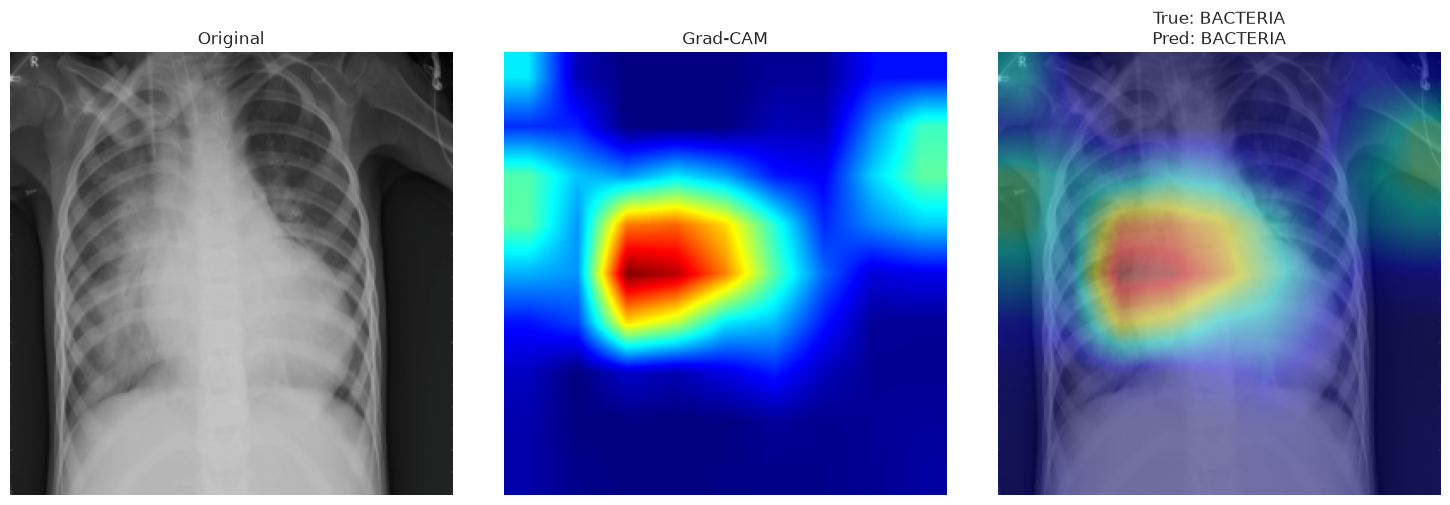

✅ Grad-CAM image saved successfully.


In [22]:
# ============================================================
# Display Grad-CAM
# ============================================================

# Recover original image
image = image_tensor.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = std * image + mean
image = np.clip(image, 0, 1)

# Resize heatmap
heatmap = cv2.resize(
    cam,
    (image.shape[1], image.shape[0])
)

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

overlay = heatmap.astype(np.float32) / 255 * 0.4 + image * 0.6
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[predicted_label]}"
)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    GRADCAM_DIR / "gradcam_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Grad-CAM image saved successfully.")

# Find Representative Test Images

Automatically select one correctly classified image with the highest confidence from each class.

In [23]:
# ============================================================
# Find Best Representative Images
# ============================================================

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)

best_examples = {}

model.eval()

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, label = test_dataset[idx]

        input_tensor = image.unsqueeze(0).to(DEVICE)

        output = model(input_tensor)

        prob = torch.softmax(output, dim=1)

        confidence, prediction = torch.max(prob, 1)

        prediction = prediction.item()
        confidence = confidence.item()

        # Keep only correctly classified samples
        if prediction != label:
            continue

        # Highest confidence image of each class
        if label not in best_examples:

            best_examples[label] = (
                idx,
                confidence
            )

        else:

            if confidence > best_examples[label][1]:

                best_examples[label] = (
                    idx,
                    confidence
                )

print("=" * 60)

for label in sorted(best_examples):

    idx, conf = best_examples[label]

    print(
        f"{CLASS_NAMES[label]:10s}  Image #{idx:4d}  Confidence={conf:.4f}"
    )

print("=" * 60)

BACTERIA    Image # 229  Confidence=0.9538
NORMAL      Image # 636  Confidence=0.9766
VIRUS       Image # 796  Confidence=0.9746


# Generate Grad-CAM for Representative Images

Generate Grad-CAM visualizations for the highest-confidence correctly classified image from each class.

# Grad-CAM Utility Functions

Define reusable functions to generate, visualize, and save Grad-CAM heatmaps.

In [24]:
# ============================================================
# Grad-CAM Utility Functions
# ============================================================

def generate_gradcam(image_tensor, class_index=None):

    model.zero_grad()

    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    outputs = model(input_tensor)

    if class_index is None:
        class_index = outputs.argmax(dim=1).item()

    outputs[:, class_index].backward()

    gradients = gradcam.gradients[0]
    activations = gradcam.activations[0]

    weights = gradients.mean(dim=(1, 2))

    cam = torch.zeros(
        activations.shape[1:],
        device=DEVICE
    )

    for i, w in enumerate(weights):
        cam += w * activations[i]

    cam = torch.relu(cam)

    cam -= cam.min()

    cam /= (cam.max() + 1e-8)

    return cam.cpu().numpy(), class_index


def tensor_to_image(image_tensor):

    image = image_tensor.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean

    image = np.clip(image, 0, 1)

    return image


def overlay_heatmap(image, cam):

    heatmap = cv2.resize(
        cam,
        (image.shape[1], image.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        image * 0.6 +
        heatmap.astype(np.float32) / 255 * 0.4
    )

    overlay = np.clip(overlay, 0, 1)

    return heatmap, overlay


print("✅ Grad-CAM utility functions created.")

✅ Grad-CAM utility functions created.


# Generate Representative Grad-CAM Images

Generate and save Grad-CAM visualizations for the highest-confidence correctly classified image from each class.

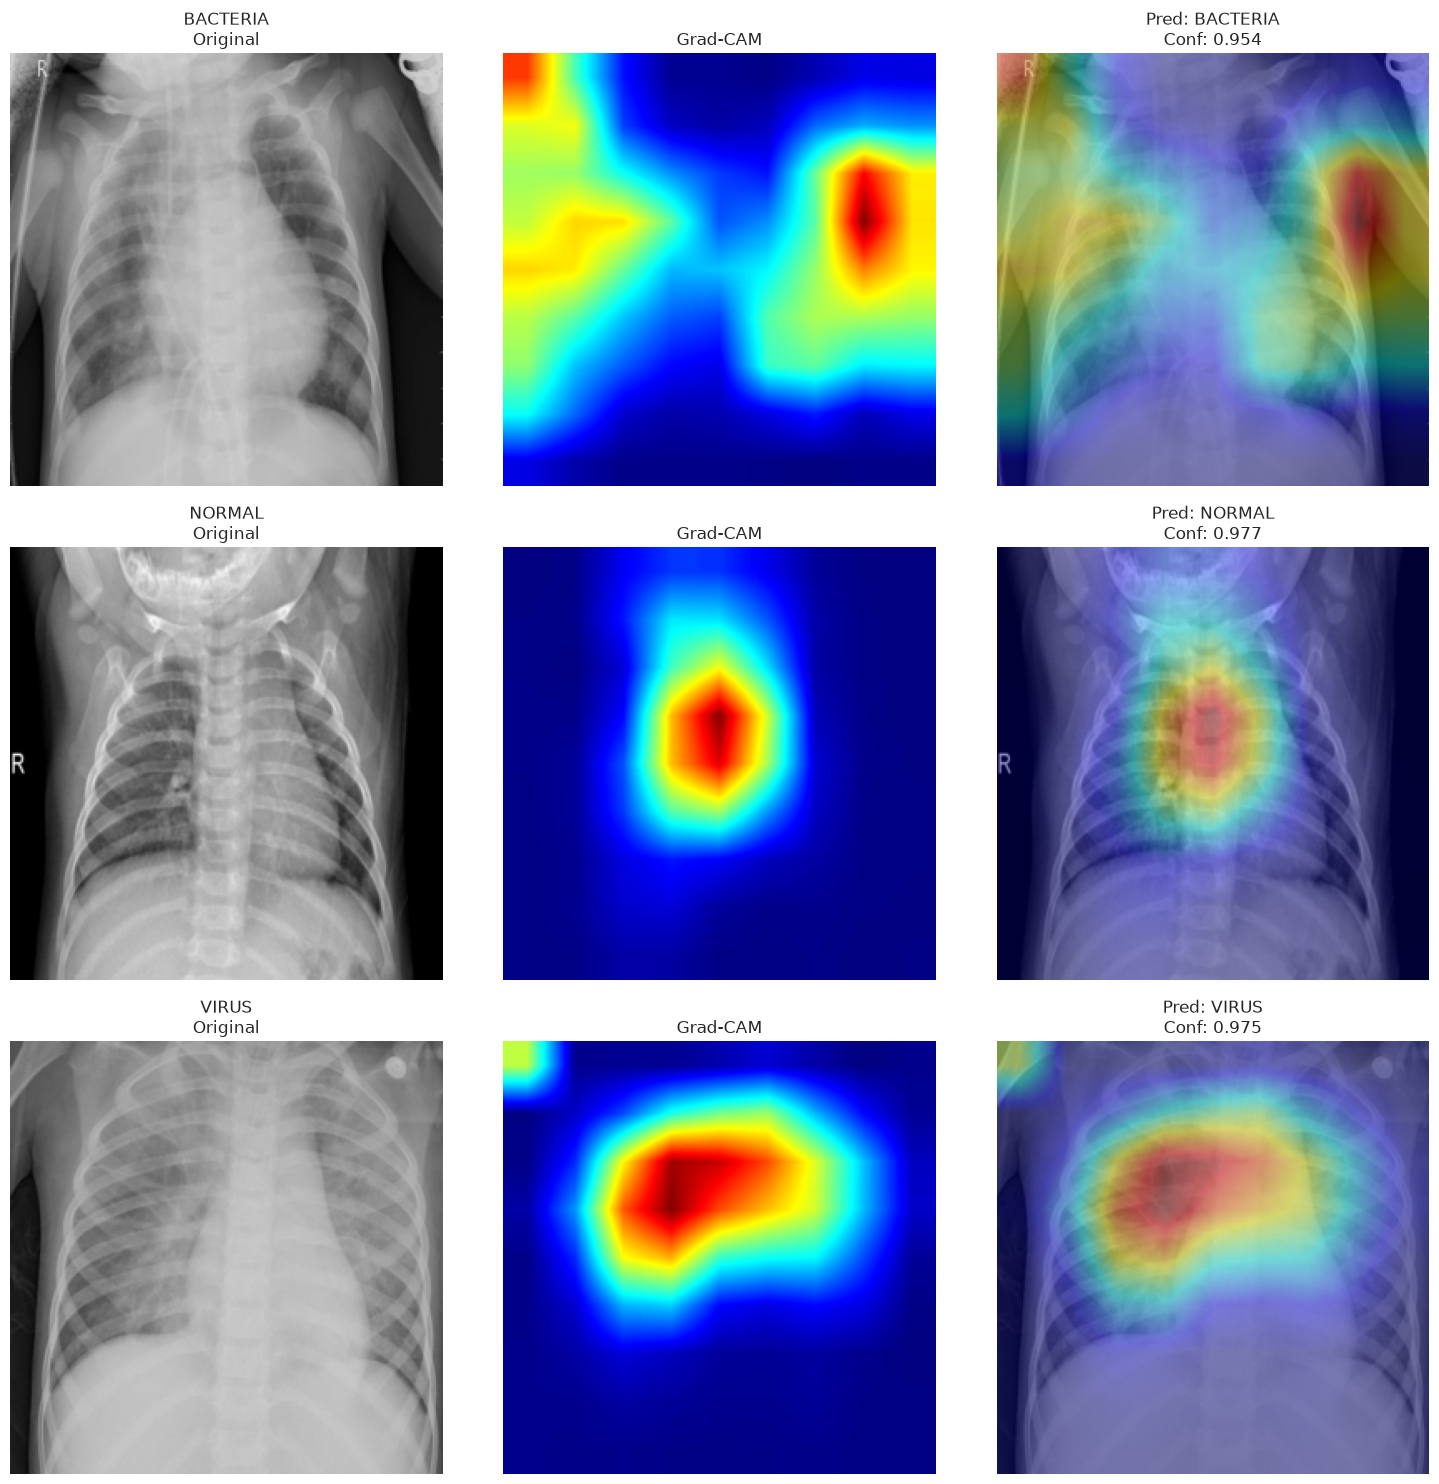

✅ Representative Grad-CAM Images Generated
Saved to: /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/results/gradcam


In [25]:
# ============================================================
# Generate & Save Representative Grad-CAM Images
# ============================================================

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(15, 15))

for row, label in enumerate(sorted(best_examples.keys())):

    image_index, confidence = best_examples[label]

    image_tensor, true_label = test_dataset[image_index]

    cam, predicted_class = generate_gradcam(image_tensor)

    original = tensor_to_image(image_tensor)

    heatmap, overlay = overlay_heatmap(original, cam)

    # -----------------------------
    # Original
    # -----------------------------
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(
        f"{CLASS_NAMES[true_label]}\nOriginal"
    )
    axes[row, 0].axis("off")

    # -----------------------------
    # Heatmap
    # -----------------------------
    axes[row, 1].imshow(heatmap)
    axes[row, 1].set_title("Grad-CAM")
    axes[row, 1].axis("off")

    # -----------------------------
    # Overlay
    # -----------------------------
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"Pred: {CLASS_NAMES[predicted_class]}\nConf: {confidence:.3f}"
    )
    axes[row, 2].axis("off")

    # Save each class separately
    plt.imsave(
        GRADCAM_DIR / f"{CLASS_NAMES[true_label].lower()}_correct.png",
        overlay
    )

plt.tight_layout()

plt.savefig(
    GRADCAM_DIR / "gradcam_paper_figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("✅ Representative Grad-CAM Images Generated")
print("Saved to:", GRADCAM_DIR)
print("=" * 60)